uploading
file

Libraries

In [24]:
from google.colab import files
uploaded = files.upload()

Saving placementdata.xlsx to placementdata (6).xlsx


In [25]:
import pandas as pd

df = pd.read_excel("placementdata.xlsx")
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,Hackerrank,Leetcode,coding contests,coding score,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,233,42,6,335,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,194,164,7,428,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,170,110,6,340,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,63,50,2,133,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,53,85,3,168,Placed


Preprocessing


In [26]:
df.isnull().sum()

,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


In [27]:
df["ExtracurricularActivities"] = df["ExtracurricularActivities"].map({"Yes":1,"No":0})
df["PlacementTraining"] = df["PlacementTraining"].map({"Yes":1,"No":0})
df["PlacementStatus"] = df["PlacementStatus"].map({"Placed":1,"NotPlaced":0})

In [28]:
df = df.drop("StudentID",axis=1)

In [29]:
df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,Hackerrank,Leetcode,coding contests,coding score,PlacementStatus
0,7.5,1,1,1,65,4.4,0,0,61,79,233,42,6,335,0
1,8.9,0,3,2,90,4.0,1,1,78,82,194,164,7,428,1
2,7.3,1,2,2,82,4.8,1,0,79,80,170,110,6,340,0
3,7.5,1,1,2,85,4.4,1,1,81,80,63,50,2,133,1
4,8.3,1,2,2,86,4.5,1,1,74,88,53,85,3,168,1


splitting data


In [30]:
from sklearn.model_selection import train_test_split

X = df.drop("PlacementStatus",axis=1)
y = df["PlacementStatus"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

Decision tree


In [31]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [32]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.7105


In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "max_depth":[3,4,5,6,7,8],
    "min_samples_split":[2,4,6,8],
    "min_samples_leaf":[1,2,3,4]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7785


In [34]:
df["CodingScore"] = df["Hackerrank"] + df["Leetcode"]
df["AcademicScore"] = (df["SSC_Marks"] + df["HSC_Marks"] + df["CGPA"]*10)/3

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = ["CGPA","SSC_Marks","HSC_Marks","Hackerrank","Leetcode"]

df[num_cols] = scaler.fit_transform(df[num_cols])

**Random Forest**

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.788


In [37]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[964 208]
 [216 612]]
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1172
           1       0.75      0.74      0.74       828

    accuracy                           0.79      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.79      0.79      0.79      2000



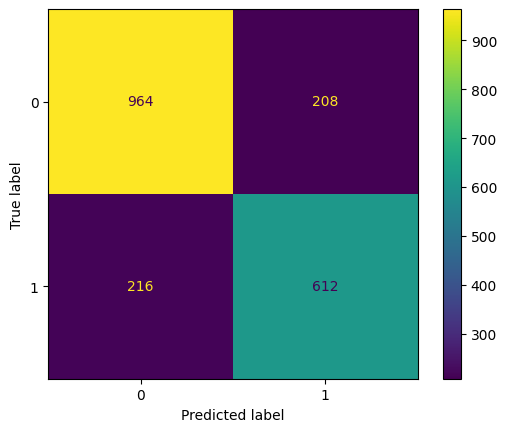

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

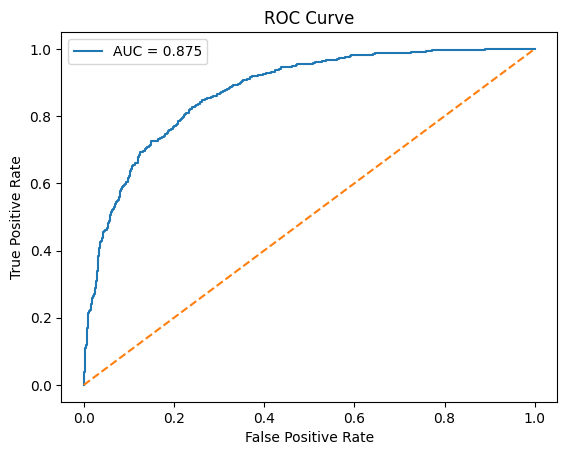

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc, 3)))
plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()